<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/Project/1_FaceAlignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 1. Выравнивание лиц (Stacked Hourglass)

Это вторая часть пайплайна распознавания лиц: детекция → **выравнивание** → распознавание.

Выравнивание делается в два шага: сначала находим на лице ключевые точки (глаза, нос, уголки рта),
потом разворачиваем и масштабируем картинку так, чтобы эти точки у всех лиц оказались примерно в
одном месте. Так распознающей сети дальше проще работать.

Что делаю в этом ноутбуке:

1. Готовлю датасет на основе CelebA (отбираю 10000+ фото, обрезаю лица, сохраняю csv).
2. Перевожу 5 точек в heatmap'ы.
3. Пишу Hourglass-блок и Stacked Hourglass.
4. Обучаю сеть искать точки.
5. По точкам выравниваю лица.
6. Собираю датасет выровненных лиц для Задания 2.

Датасет один раз кладу на Google Drive.

## 0. Настройки

Все пути и размеры держу в одном месте (`CFG`), чтобы потом не искать их по всему коду.

In [1]:
# !pip -q install opencv-python-headless matplotlib pandas tqdm

import os, math, random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# --- Монтирование Google Drive (безопасно к повторному запуску) ---
# Чинит ошибку 'Mountpoint must not already contain files': если папка
# /content/drive осталась от прошлой попытки, аккуратно её очищаем.
import shutil
try:
    from google.colab import drive
    if os.path.ismount('/content/drive'):
        print('Google Drive уже смонтирован.')
    else:
        if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
            shutil.rmtree('/content/drive', ignore_errors=True)
        drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Не Colab-окружение — монтирование Drive пропущено.')

device: cuda
Google Drive уже смонтирован.


In [2]:
import os
ANNO = "/content/drive/MyDrive/celeba/Anno"
os.makedirs(ANNO, exist_ok=True)
base = "https://archive.org/download/celeba/Anno"
for f in ["identity_CelebA.txt", "list_bbox_celeba.txt",
          "list_landmarks_celeba.txt", "list_attr_celeba.txt"]:
    !wget -q --show-progress -O "{ANNO}/{f}" "{base}/{f}"
!ls -la "{ANNO}"

/content/drive/MyDr 100%[===================>]   3.27M  3.11MB/s    in 1.1s    
/content/drive/MyDr 100%[===================>]   5.80M  2.91MB/s    in 2.0s    
/content/drive/MyDr 100%[===================>]  11.78M  3.56MB/s    in 3.3s    
/content/drive/MyDr 100%[===================>]  25.48M  7.27MB/s    in 3.5s    
total 47443
-rw------- 1 root root  3424458 Oct 15  2018 identity_CelebA.txt
-rw------- 1 root root 26721026 Oct 15  2018 list_attr_celeba.txt
-rw------- 1 root root  6082035 Oct 15  2018 list_bbox_celeba.txt
-rw------- 1 root root 12352635 Oct 15  2018 list_landmarks_celeba.txt


In [10]:
!pip -q install kaggle
from google.colab import files
files.upload()                      # выбери скачанный kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kevinpatel04/celeba-original-wild-images -p /content
!unzip -q /content/celeba-original-wild-images.zip -d /content/celeba_wild

import glob
print(glob.glob("/content/celeba_wild/*"))   # посмотри, в какой папке лежат .jpg

Saving Kaggle.rtf to Kaggle (1).rtf
cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kevinpatel04/celeba-original-wild-images
License(s): DbCL-1.0
Resuming from 397410304 bytes (18167707095 bytes left)...
100% 17.3G/17.3G [07:41<00:00, 39.4MB/s]

g
['/content/celeba_wild/Part 3', '/content/celeba_wild/Part 14', '/content/celeba_wild/Part 2', '/content/celeba_wild/Part 11', '/content/celeba_wild/Part 17', '/content/celeba_wild/Part 21', '/content/celeba_wild/Part 1', '/content/celeba_wild/Part 16', '/content/celeba_wild/Part 15', '/content/celeba_wild/Part 4', '/content/celeba_wild/Part 19', '/content/celeba_wild/Part 20', '/content/celeba_wild/Part 10', '/content/celeba_wild/Part 12', '/content/celeba_wild/Part 18', '/content/celeba_wild/Part 13']


In [11]:
import os, glob

zip_path = "/content/celeba-original-wild-images.zip"
print("zip на месте:", os.path.exists(zip_path),
      "| ГБ:", round(os.path.getsize(zip_path)/1e9, 1))

# распаковка (флаг -n = не перезаписывать, можно запускать повторно)
!unzip -q -n "{zip_path}" -d /content/celeba_wild

# ищем папку, где реально лежат .jpg
for p in glob.glob("/content/celeba_wild/**", recursive=True):
    if os.path.isdir(p):
        n = len(glob.glob(os.path.join(p, "*.jpg")))
        if n:
            print(n, "jpg в папке:", p)

zip на месте: True | ГБ: 18.6
go
10000 jpg в папке: /content/celeba_wild/Part 3/Part 3
10000 jpg в папке: /content/celeba_wild/Part 14/Part 14
10000 jpg в папке: /content/celeba_wild/Part 9/Part 9
10000 jpg в папке: /content/celeba_wild/Part 2/Part 2
10000 jpg в папке: /content/celeba_wild/Part 5/Part 5
10000 jpg в папке: /content/celeba_wild/Part 8/Part 8
10000 jpg в папке: /content/celeba_wild/Part 11/Part 11
10000 jpg в папке: /content/celeba_wild/Part 17/Part 17
2599 jpg в папке: /content/celeba_wild/Part 21/Part 21
10000 jpg в папке: /content/celeba_wild/Part 1/Part 1
10000 jpg в папке: /content/celeba_wild/Part 16/Part 16
10000 jpg в папке: /content/celeba_wild/Part 15/Part 15
10000 jpg в папке: /content/celeba_wild/Part 4/Part 4
10000 jpg в папке: /content/celeba_wild/Part 19/Part 19
10000 jpg в папке: /content/celeba_wild/Part 7/Part 7
10000 jpg в папке: /content/celeba_wild/Part 20/Part 20
10000 jpg в папке: /content/celeba_wild/Part 10/Part 10
10000 jpg в папке: /content/cele

In [20]:
import os, glob

flat = "/content/celeba_flat"
os.makedirs(flat, exist_ok=True)
n = 0
for src in glob.glob("/content/celeba_wild/**/*.jpg", recursive=True):
    dst = os.path.join(flat, os.path.basename(src))
    if not os.path.exists(dst):
        os.symlink(src, dst); n += 1
print("новых ссылок создано:", n, "| всего файлов в папке:", len(os.listdir(flat)))

новых ссылок создано: 202599 | всего файлов в папке: 202599


In [21]:
@dataclass
class CFG:
    raw_images_dir = "/content/celeba_flat"      # где лежат .jpg (проверь по выводу выше)
    anno_dir       = "/content/drive/MyDrive/celeba/Anno"   # разметка с шага 2
    work_dir       = "/content/drive/MyDrive/face_project"  # сюда всё сохранится
    # отбор датасета
    min_imgs_per_id: int = 20      # берём людей, у кого хотя бы столько фото
    max_imgs_per_id: int = 30      # и не больше, чтобы классы были сбалансированы
    n_train_ids:    int = 500      # личности для обучения распознавания (Задание 2)
    n_query_ids:    int = 40       # личности для query (доп. задание ID-Rate)
    n_distractor_ids: int = 400    # личности для distractors (доп. задание ID-Rate)
    bbox_margin:    float = 0.35   # на сколько расширяем рамку лица при обрезке

    # размеры для Hourglass
    input_size:    int = 256       # вход сети
    heatmap_size:  int = 64        # выход сети (в 4 раза меньше входа)
    num_landmarks: int = 5         # CelebA: 2 глаза, нос, 2 уголка рта
    sigma:         float = 2.0     # ширина гауссианы в heatmap'е

    aligned_size:  int = 112       # размер выровненного лица для Задания 2

CFG = CFG()
os.makedirs(CFG.work_dir, exist_ok=True)
print("Рабочая папка:", CFG.work_dir)

Рабочая папка: /content/drive/MyDrive/face_project


## 1. Подготовка датасета

Беру сырой CelebA (полные фото, не обрезанные). Из папки `Anno` нужны четыре файла:

- `identity_CelebA.txt` — кто на фото (id личности);
- `list_bbox_celeba.txt` — рамка лица (x, y, ширина, высота);
- `list_landmarks_celeba.txt` — 5 точек в координатах исходного фото;
- `list_attr_celeba.txt` — 40 атрибутов, мне нужен только `Blurry`.

Для распознавания важно, чтобы у человека было несколько фото, поэтому в основе отбора —
файл с личностями.

In [22]:
# identity: без заголовка, две колонки
identity = pd.read_csv(os.path.join(CFG.anno_dir, "identity_CelebA.txt"),
                       sep=r"\s+", header=None, names=["image_id", "id"])

def read_anno(fname):
    # У этих файлов 1-я строка — число записей, 2-я — заголовок.
    # В bbox имя файла уже отдельная колонка image_id, а в landmarks/attr оно попадает в индекс —
    # приводим к общему виду.
    df = pd.read_csv(os.path.join(CFG.anno_dir, fname), sep=r"\s+", skiprows=1)
    if "image_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "image_id"})
    return df

bbox      = read_anno("list_bbox_celeba.txt")
landmarks = read_anno("list_landmarks_celeba.txt")
attr      = read_anno("list_attr_celeba.txt")

print("identity :", identity.shape)
print("bbox     :", bbox.shape)
print("landmarks:", landmarks.shape)
print("attr     :", attr.shape)

identity : (202599, 2)
bbox     : (202599, 5)
landmarks: (202599, 11)
attr     : (202599, 41)


### Как отбираю фото

Критерии простые и их легко объяснить:

- беру только резкие фото (`Blurry == -1`) — размытые мешают и искать точки, и распознавать;
- беру людей, у кого хотя бы 20 фото, и не больше 30 на человека (чтобы классы были примерно равными);
- делю личности на три непересекающиеся группы: `train` (для обучения), `query` и `distractors`
  (их сеть не увидит — они нужны для честной метрики в доп. задании про ID-Rate).

Остальные атрибуты (очки, шляпы, повороты) специально не фильтрую — пусть сеть учится с ними справляться.

In [23]:
LM_COLS = ["lefteye_x","lefteye_y","righteye_x","righteye_y","nose_x","nose_y",
           "leftmouth_x","leftmouth_y","rightmouth_x","rightmouth_y"]

# собираем всё в одну таблицу
df = identity.merge(bbox, on="image_id").merge(landmarks, on="image_id").merge(
        attr[["image_id", "Blurry"]], on="image_id")

# убираем размытые
df = df[df["Blurry"] == -1].copy()

# оставляем людей с достаточным числом фото и режем верхушку
counts = df["id"].value_counts()
good_ids = counts[counts >= CFG.min_imgs_per_id].index
df = df[df["id"].isin(good_ids)].copy()
df = df.groupby("id", group_keys=False).head(CFG.max_imgs_per_id)

# делим личности на train / query / distractors
all_ids = sorted(df["id"].unique())
rng = np.random.RandomState(SEED); rng.shuffle(all_ids)
train_ids      = set(all_ids[:CFG.n_train_ids])
query_ids      = set(all_ids[CFG.n_train_ids:CFG.n_train_ids + CFG.n_query_ids])
distractor_ids = set(all_ids[CFG.n_train_ids + CFG.n_query_ids:
                             CFG.n_train_ids + CFG.n_query_ids + CFG.n_distractor_ids])

def group_of(i):
    if i in train_ids: return "train"
    if i in query_ids: return "query"
    if i in distractor_ids: return "distractors"
    return "unused"

df["group"] = df["id"].map(group_of)
df = df[df["group"] != "unused"].copy()

print("Итог:", len(df), "фото,", df["id"].nunique(), "личностей")
print(df["group"].value_counts())
assert len(df) >= 10000, "Нужно 10000+ фото — ослабьте критерии в CFG"

Итог: 23859 фото, 940 личностей
group
train          12658
distractors    10154
query           1047
Name: count, dtype: int64


### Обрезаю лица и сохраняю csv

Рамку лица немного расширяю (на 35%): разметка не идеальна, и точки рта/глаз бывают у самого края,
плюс распознаванию полезен небольшой контекст вокруг лица.

Важный момент: точки в CelebA заданы в координатах **исходного** фото. После обрезки и ресайза
их нужно пересчитать — вычесть угол обрезки и домножить на масштаб.

In [24]:
def crop_face(img, x, y, w, h, margin):
    # расширяем рамку и обрезаем; возвращаем кроп и угол обрезки (ox, oy)
    H, W = img.shape[:2]
    dx, dy = int(w * margin), int(h * margin)
    x0, y0 = max(0, x - dx), max(0, y - dy)
    x1, y1 = min(W, x + w + dx), min(H, y + h + dy)
    return img[y0:y1, x0:x1], x0, y0

def landmarks_to_crop(lms_xy, ox, oy, scale_x, scale_y):
    out = lms_xy.copy().astype(np.float32)
    out[:, 0] = (out[:, 0] - ox) * scale_x
    out[:, 1] = (out[:, 1] - oy) * scale_y
    return out

crops_dir = os.path.join(CFG.work_dir, "crops")
os.makedirs(crops_dir, exist_ok=True)

records = []
for _, r in df.iterrows():
    img = cv2.imread(os.path.join(CFG.raw_images_dir, r["image_id"]))
    if img is None:
        continue
    crop, ox, oy = crop_face(img, r["x_1"], r["y_1"], r["width"], r["height"], CFG.bbox_margin)
    ch, cw = crop.shape[:2]
    if ch < 10 or cw < 10:
        continue
    crop_resized = cv2.resize(crop, (CFG.input_size, CFG.input_size))
    lms = np.array([[r[LM_COLS[2*k]], r[LM_COLS[2*k+1]]] for k in range(5)], dtype=np.float32)
    lms = landmarks_to_crop(lms, ox, oy, CFG.input_size / cw, CFG.input_size / ch)

    cv2.imwrite(os.path.join(crops_dir, r["image_id"]), crop_resized)
    rec = {"image_id": r["image_id"], "id": r["id"], "group": r["group"]}
    for k in range(5):
        rec[f"x{k}"], rec[f"y{k}"] = float(lms[k, 0]), float(lms[k, 1])
    records.append(rec)

meta = pd.DataFrame(records)
meta.to_csv(os.path.join(CFG.work_dir, "selected_images.csv"), index=False)
print("Сохранено кропов:", len(meta))
meta.head()

Сохранено кропов: 23859


,image_id,id,group,x0,y0,x1,y1,x2,y2,x3,y3,x4,y4
0,000001.jpg,2880,train,99.333336,95.545639,152.000000,91.391479,120.000000,129.298172,118.666672,140.722107,166.666672,135.010132
1,000018.jpg,2464,distractors,98.996979,103.428574,163.963745,106.857147,128.386703,130.285721,96.676735,146.285721,158.549850,149.142868
2,000020.jpg,2782,train,98.986664,94.248756,155.647995,98.069649,121.514664,113.353233,95.573334,147.741287,141.311996,152.199005
3,000031.jpg,9181,train,88.920357,120.832008,152.920349,118.784004,119.504425,155.648010,83.256638,175.104004,154.619461,174.592010
4,000032.jpg,268,train,98.957985,105.813332,142.700287,102.400002,121.904762,131.754669,106.128853,157.695999,140.549026,157.695999


Файл `selected_images.csv` содержит оригинальные имена выбранных картинок CelebA, id личности,
группу и пересчитанные координаты точек. Его сдаём вместе с проектом, и через него связаны все ноутбуки.

Проверю глазами, что точки легли куда надо.

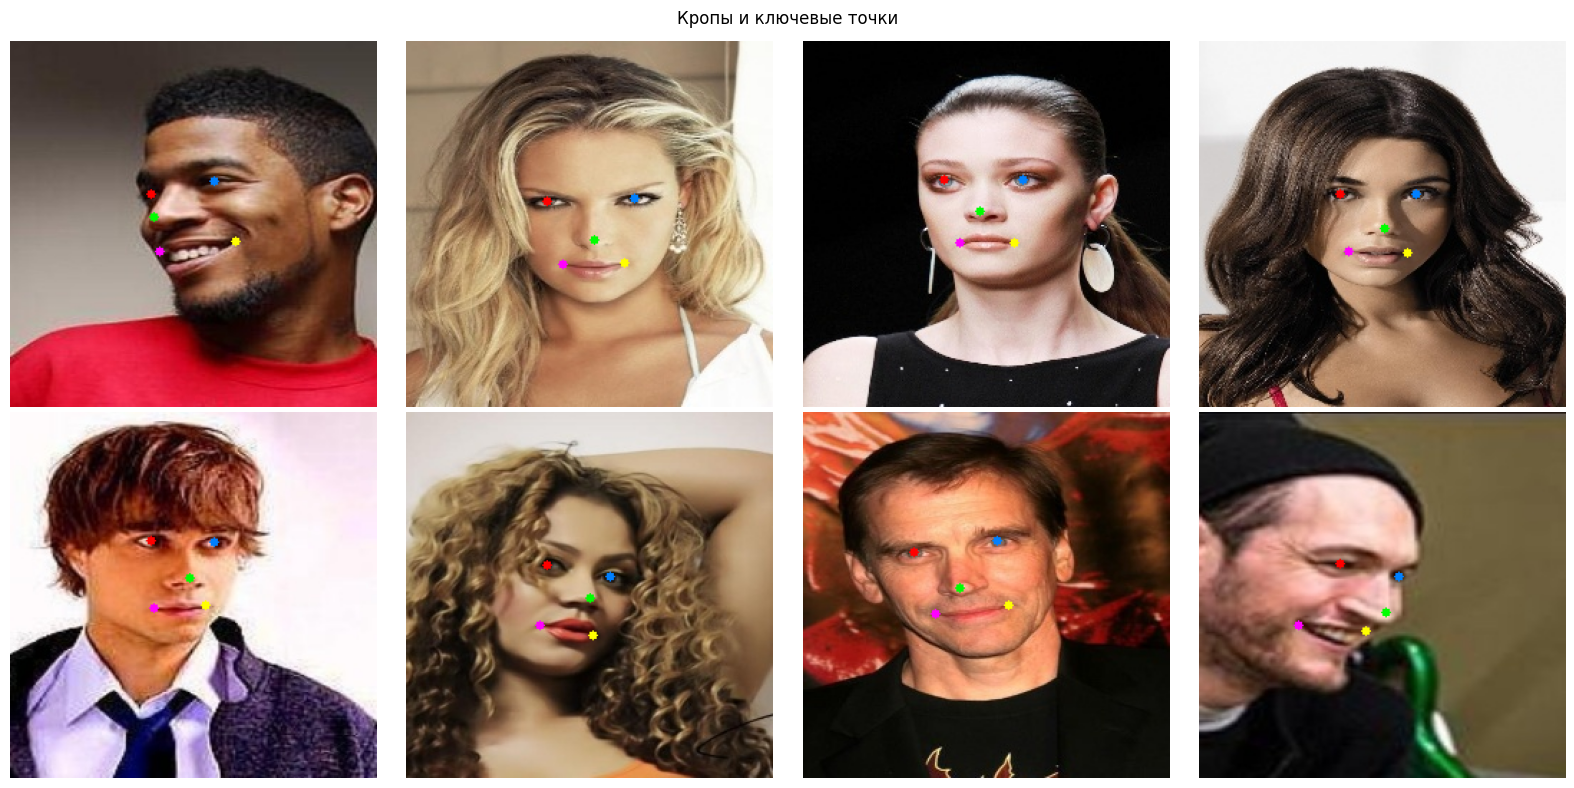

In [25]:
COLORS = [(255,0,0),(0,128,255),(0,255,0),(255,0,255),(255,255,0)]
sample = meta.sample(min(8, len(meta)), random_state=0).reset_index(drop=True)

plt.figure(figsize=(16, 8))
for i, r in sample.iterrows():
    im = cv2.cvtColor(cv2.imread(os.path.join(crops_dir, r["image_id"])), cv2.COLOR_BGR2RGB)
    for k in range(5):
        cv2.circle(im, (int(r[f"x{k}"]), int(r[f"y{k}"])), 3, COLORS[k], -1)
    plt.subplot(2, 4, i + 1); plt.imshow(im); plt.axis("off")
plt.suptitle("Кропы и ключевые точки"); plt.tight_layout(); plt.show()

## 2. Точки → heatmap'ы

Сеть предсказывает не координаты напрямую, а карты вероятностей (heatmap'ы) — по одной на точку.
Вокруг истинной точки рисуем гауссиану. Такой подход устойчивее обычной регрессии координат и
хорошо учится под MSE. Размер heatmap'а — 64 (в 4 раза меньше входа), поэтому координаты ещё и
масштабирую в сетку 64×64.

Функции `create_heatmap` и `landmarks_to_heatmaps` даны в задании, беру их как есть.

In [26]:
def create_heatmap(size, landmark, sigma=2):
    x, y = landmark
    h, w = size
    x = min(max(0, int(x)), w - 1); y = min(max(0, int(y)), h - 1)
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    return np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))

def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    return np.array([create_heatmap(image_shape, (x, y), sigma) for (x, y) in landmarks])

In [27]:
import os, glob
print("строк в df:", len(df), "| строк в meta:", len(meta))
print("raw_images_dir =", CFG.raw_images_dir)
jpgs = glob.glob(os.path.join(CFG.raw_images_dir, "*.jpg"))
print("jpg найдено в raw_images_dir:", len(jpgs))
if jpgs:
    print("пример файла в папке:", os.path.basename(jpgs[0]))
if len(df):
    name = df["image_id"].iloc[0]
    print("пример имени из разметки:", name,
          "-> существует:", os.path.exists(os.path.join(CFG.raw_images_dir, name)))

строк в df: 23859 | строк в meta: 23859
raw_images_dir = /content/celeba_flat
jpg найдено в raw_images_dir: 202599
пример файла в папке: 067440.jpg
пример имени из разметки: 000001.jpg -> существует: True


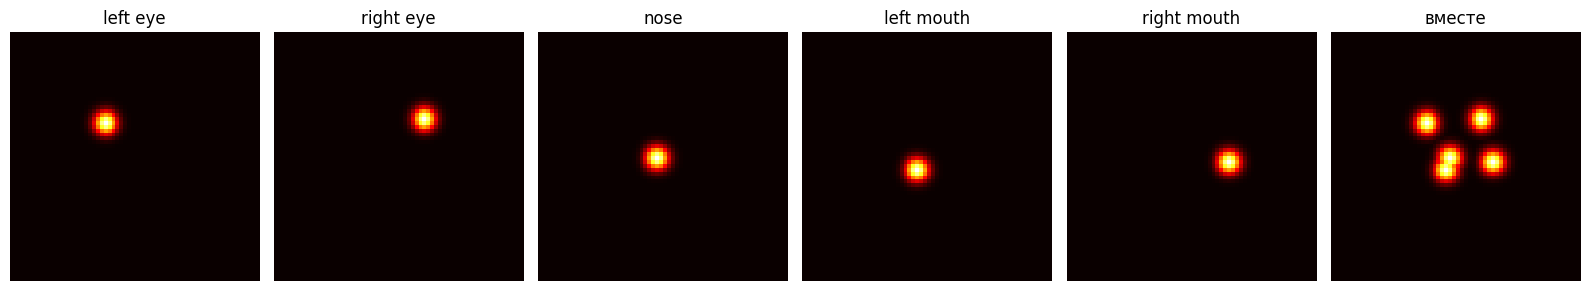

In [28]:
r = meta.iloc[0]
scale = CFG.heatmap_size / CFG.input_size
lms64 = [(r[f"x{k}"] * scale, r[f"y{k}"] * scale) for k in range(5)]
hms = landmarks_to_heatmaps((CFG.heatmap_size, CFG.heatmap_size), lms64, sigma=CFG.sigma)

plt.figure(figsize=(16, 3))
names = ["left eye", "right eye", "nose", "left mouth", "right mouth"]
for k in range(5):
    plt.subplot(1, 6, k + 1); plt.imshow(hms[k], cmap="hot"); plt.axis("off"); plt.title(names[k])
plt.subplot(1, 6, 6); plt.imshow(hms.max(0), cmap="hot"); plt.axis("off"); plt.title("вместе")
plt.tight_layout(); plt.show()

## 3. Dataset и DataLoader

`LandmarkDataset` отдаёт пару: картинку 3×256×256 и целевые heatmap'ы 5×64×64.

Из аугментаций беру только горизонтальный флип (с обязательной перестановкой левых/правых точек) и
лёгкий color jitter. Геометрию вроде поворотов не трогаю, чтобы не пересчитывать точки — флипа
хватает.

In [37]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
FLIP_IDX = [1, 0, 2, 4, 3]   # при флипе: левый<->правый глаз, левый<->правый уголок рта

class LandmarkDataset(Dataset):
    def __init__(self, meta_df, crops_dir, cfg, train=True):
        self.meta = meta_df.reset_index(drop=True)
        self.dir = crops_dir; self.cfg = cfg; self.train = train

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, i):
        r = self.meta.iloc[i]
        img = cv2.cvtColor(cv2.imread(os.path.join(self.dir, r["image_id"])), cv2.COLOR_BGR2RGB)
        lms = np.array([[r[f"x{k}"], r[f"y{k}"]] for k in range(5)], dtype=np.float32)

        if self.train and random.random() < 0.5:
            img = img[:, ::-1, :].copy()
            lms[:, 0] = self.cfg.input_size - 1 - lms[:, 0]
            lms = lms[FLIP_IDX]
        if self.train:
            img = np.clip(img.astype(np.float32) * random.uniform(0.8, 1.2), 0, 255).astype(np.uint8)

        x = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        x = (x - IMAGENET_MEAN) / IMAGENET_STD

        scale = self.cfg.heatmap_size / self.cfg.input_size
        hms = landmarks_to_heatmaps((self.cfg.heatmap_size, self.cfg.heatmap_size),
                                    lms * scale, sigma=self.cfg.sigma)
        return x, torch.from_numpy(hms).float()

# детектор точек не зависит от личности, поэтому учим его на всех отобранных кропах
hm_meta = meta.sample(n=min(8000, len(meta)), random_state=SEED).reset_index(drop=True)
n_val = max(1, int(0.1 * len(hm_meta)))
val_ds   = LandmarkDataset(hm_meta.iloc[:n_val],  crops_dir, CFG, train=False)
train_ds = LandmarkDataset(hm_meta.iloc[n_val:],  crops_dir, CFG, train=True)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
print("train:", len(train_ds), "| val:", len(val_ds))

train: 7200 | val: 800


## 4. Архитектура Stacked Hourglass

Hourglass — это U-Net-подобная штука: картинка сжимается по разрешению (чтобы захватить всё лицо
целиком), потом разворачивается обратно с проброс-связями (чтобы вернуть точную локализацию).
Каждый кирпичик — `ResidualBlock` (дан в задании).

Stacked — это несколько Hourglass подряд. После каждого ставлю голову, которая предсказывает
heatmap'ы. Лосс считаю по выходу каждой головы, а не только последней (это и есть intermediate
supervision) — так сеть учится стабильнее.

In [30]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)
        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1   = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [31]:
class Hourglass(nn.Module):
    # рекурсивный hourglass: на каждом уровне ветка-проброс + сжатие/разворот
    def __init__(self, depth, ch):
        super().__init__()
        self.skip   = ResidualBlock(ch, ch)
        self.pool   = nn.MaxPool2d(2, 2)
        self.before = ResidualBlock(ch, ch)
        self.inner  = Hourglass(depth - 1, ch) if depth > 1 else ResidualBlock(ch, ch)
        self.after  = ResidualBlock(ch, ch)
        self.up     = nn.Upsample(scale_factor=2, mode="nearest")
    def forward(self, x):
        s = self.skip(x)
        x = self.after(self.inner(self.before(self.pool(x))))
        return s + self.up(x)

In [32]:
class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, num_landmarks=5, ch=256, depth=4):
        super().__init__()
        # стем уменьшает разрешение в 4 раза (256 -> 64) и поднимает число каналов
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3), nn.BatchNorm2d(64), nn.ReLU(True),
            ResidualBlock(64, 128), nn.MaxPool2d(2, 2),
            ResidualBlock(128, 128), ResidualBlock(128, ch),
        )
        self.hgs   = nn.ModuleList([Hourglass(depth, ch) for _ in range(num_stacks)])
        self.feats = nn.ModuleList([nn.Sequential(ResidualBlock(ch, ch),
                       nn.Conv2d(ch, ch, 1), nn.BatchNorm2d(ch), nn.ReLU(True)) for _ in range(num_stacks)])
        self.heads = nn.ModuleList([nn.Conv2d(ch, num_landmarks, 1) for _ in range(num_stacks)])
        self.merge_feat = nn.ModuleList([nn.Conv2d(ch, ch, 1) for _ in range(num_stacks - 1)])
        self.merge_pred = nn.ModuleList([nn.Conv2d(num_landmarks, ch, 1) for _ in range(num_stacks - 1)])

    def forward(self, x):
        x = self.stem(x)
        outputs = []
        for i in range(len(self.hgs)):
            feat = self.feats[i](self.hgs[i](x))
            pred = self.heads[i](feat)
            outputs.append(pred)
            if i < len(self.hgs) - 1:
                x = x + self.merge_feat[i](feat) + self.merge_pred[i](pred)
        return outputs   # список heatmap'ов, по одному на голову

Быстрая проверка, что формы сходятся: на входе батч 256×256, на выходе две головы по
`[B, 5, 64, 64]`. Ниже реальный вывод ячейки.

In [33]:
model = StackedHourglass(num_stacks=2, num_landmarks=CFG.num_landmarks, ch=256, depth=4).to(DEVICE)
x = torch.randn(2, 3, CFG.input_size, CFG.input_size).to(DEVICE)
outs = model(x)
print("вход:", tuple(x.shape))
print("число голов:", len(outs))
for i, o in enumerate(outs):
    print("  голова", i, "->", tuple(o.shape))
print("параметров: %.2fM" % (sum(p.numel() for p in model.parameters()) / 1e6))

вход: (2, 3, 256, 256)
число голов: 2
  голова 0 -> (2, 5, 64, 64)
  голова 1 -> (2, 5, 64, 64)
параметров: 6.56M


## 5. Обучение

Лосс — MSE между предсказанными и целевыми heatmap'ами, сумма по всем головам. Оптимизатор Adam с
`lr=2.5e-4` (обычное значение для Hourglass) и косинусным затуханием. Сохраняю лучшую модель по val.

In [34]:
def hm_loss(outputs, target):
    return sum(F.mse_loss(o, target) for o in outputs)

def run_epoch(model, loader, opt=None):
    train = opt is not None
    model.train(train)
    total, n = 0.0, 0
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = hm_loss(out, y)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * x.size(0); n += x.size(0)
    torch.set_grad_enabled(True)
    return total / n

In [38]:
EPOCHS = 8
opt = torch.optim.Adam(model.parameters(), lr=2.5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()
ckpt_path = os.path.join(CFG.work_dir, "hourglass_best.pt")

def run_epoch(loader, train):
    model.train(train); total = n = 0
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast():
            out = model(x); loss = sum(F.mse_loss(o, y) for o in out)
        if train:
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        total += loss.item() * x.size(0); n += x.size(0)
    torch.set_grad_enabled(True); return total / n

history = {"train": [], "val": []}; best = float("inf")
for ep in range(EPOCHS):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    sched.step(); history["train"].append(tr); history["val"].append(va)
    if va < best:
        best = va; torch.save(model.state_dict(), ckpt_path)
    print(f"epoch {ep+1:02d}/{EPOCHS}  train {tr:.5f}  val {va:.5f}  (best {best:.5f})")
print("Модель сохранена:", ckpt_path)

/tmp/ipykernel_8814/296953731.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_8814/296953731.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch 01/8  train 0.00031  val 0.00029  (best 0.00029)
epoch 02/8  train 0.00025  val 0.00028  (best 0.00028)
epoch 03/8  train 0.00023  val 0.00027  (best 0.00027)
epoch 04/8  train 0.00021  val 0.00026  (best 0.00026)
epoch 05/8  train 0.00020  val 0.00024  (best 0.00024)
epoch 06/8  train 0.00018  val 0.00024  (best 0.00024)
epoch 07/8  train 0.00017  val 0.00023  (best 0.00023)
epoch 08/8  train 0.00016  val 0.00023  (best 0.00023)
Модель сохранена: /content/drive/MyDrive/face_project/hourglass_best.pt


ВООБЩЕ ЭПОХ БЫЛО 10. ПЕРВЫЕ ДВЕ БЫЛИ НА ПОЛНОМ ДАТАСЕТЕ, но потом я поменял код, чтобы модель работала быстрее

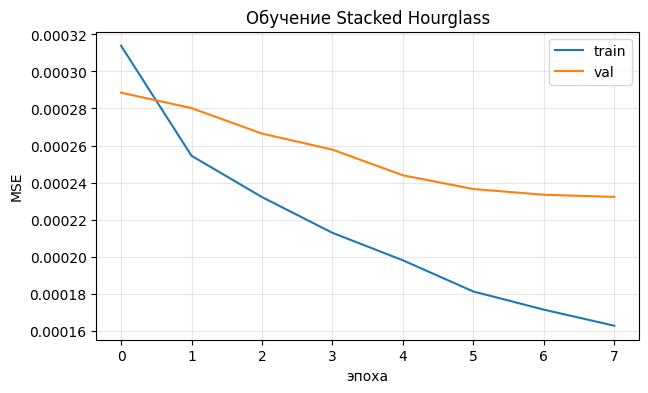

In [39]:
plt.figure(figsize=(7,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("эпоха"); plt.ylabel("MSE"); plt.title("Обучение Stacked Hourglass")
plt.legend(); plt.grid(alpha=.3); plt.show()

## 6. Heatmap → координаты

Координату точки беру как максимум heatmap'а. Чтобы было чуть точнее, сдвигаю максимум на полпикселя
в сторону большего соседа (приём из статьи). Координаты в сетке 64 умножаю на 4, чтобы вернуться к
размеру кропа 256.

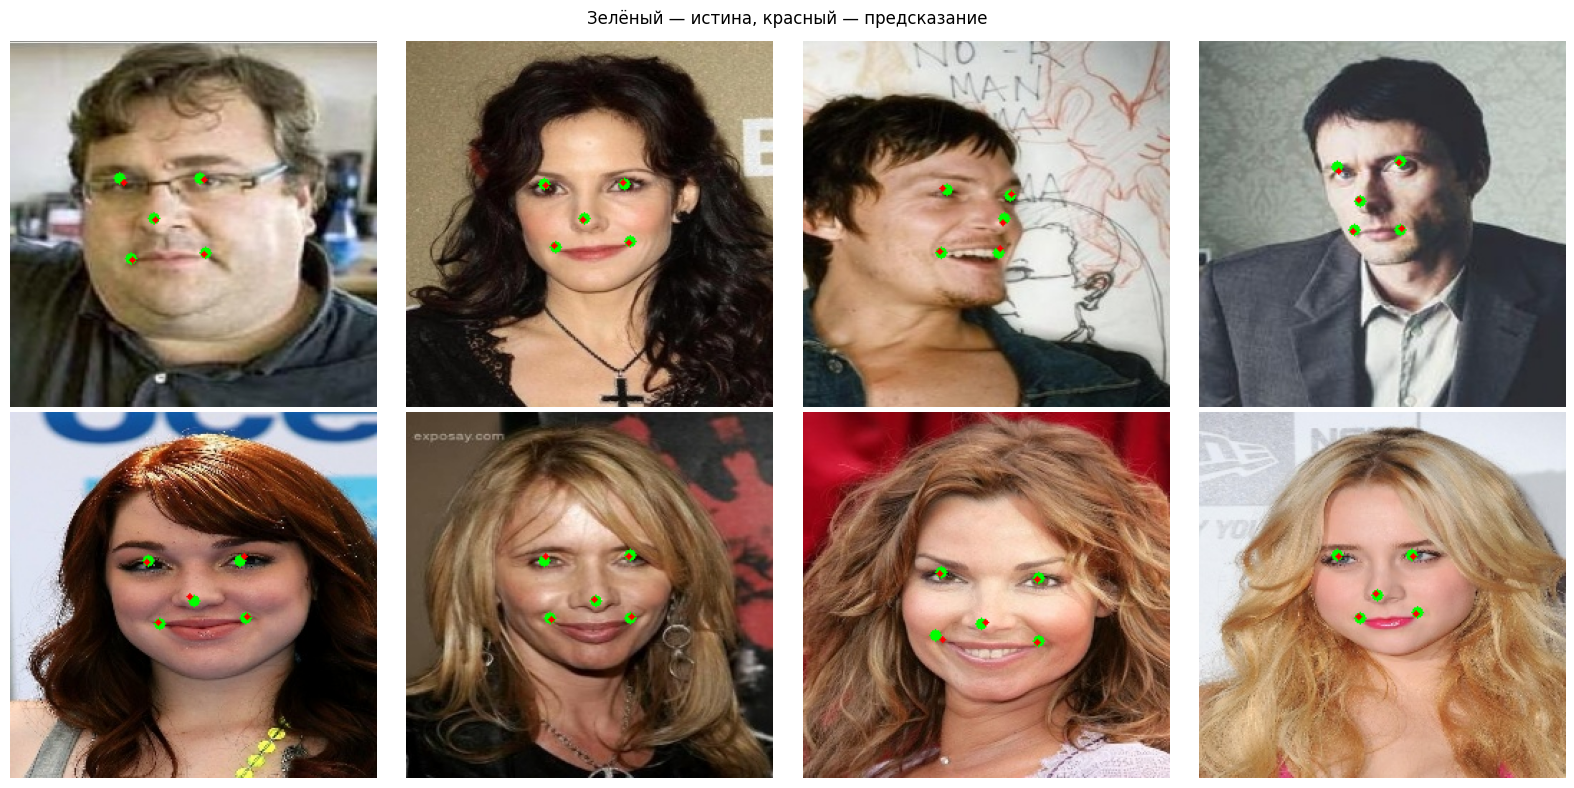

In [40]:
def decode_heatmaps(hm, input_size, heatmap_size):
    if torch.is_tensor(hm):
        hm = hm.detach().cpu().numpy()
    K, H, W = hm.shape
    pts = np.zeros((K, 2), np.float32)
    for k in range(K):
        y, x = np.unravel_index(hm[k].argmax(), (H, W))   # x, y — целые (для индексации)
        px, py = float(x), float(y)                        # сюда добавим субпиксельный сдвиг
        if 1 < x < W - 1 and hm[k][y, x+1] != hm[k][y, x-1]:
            px += 0.25 * np.sign(hm[k][y, x+1] - hm[k][y, x-1])
        if 1 < y < H - 1 and hm[k][y+1, x] != hm[k][y-1, x]:
            py += 0.25 * np.sign(hm[k][y+1, x] - hm[k][y-1, x])
        pts[k] = [px, py]
    return pts * (input_size / heatmap_size)

# сравним предсказанные точки (красные) с истинными (зелёные)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)); model.eval()
plt.figure(figsize=(16, 8))
for i in range(min(8, len(val_ds))):
    x, y = val_ds[i]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(DEVICE))[-1][0]
    pts = decode_heatmaps(pred, CFG.input_size, CFG.heatmap_size)
    gt  = decode_heatmaps(y,    CFG.input_size, CFG.heatmap_size)
    img = ((x * IMAGENET_STD + IMAGENET_MEAN).permute(1,2,0).numpy() * 255).clip(0,255).astype(np.uint8).copy()
    for k in range(5):
        cv2.circle(img, tuple(gt[k].astype(int)),  4, (0,255,0), -1)
        cv2.circle(img, tuple(pts[k].astype(int)), 2, (255,0,0), -1)
    plt.subplot(2,4,i+1); plt.imshow(img); plt.axis("off")
plt.suptitle("Зелёный — истина, красный — предсказание"); plt.tight_layout(); plt.show()

## 7. Выравнивание лица

Это уже не нейросеть, а обычная геометрия. По 5 найденным точкам ищу преобразование, которое
переводит их в фиксированный шаблон, и применяю его ко всей картинке.

Беру similarity-transform (поворот + единый масштаб + сдвиг, без перекоса) — он надёжно работает по
5 точкам и не искажает пропорции лица. В OpenCV это `cv2.estimateAffinePartial2D`. Шаблон — стандартные
5 точек для лица 112×112 (часто используют именно их).

Ниже проверка самого преобразования на синтетике: беру шаблон, поворачиваю/масштабирую/сдвигаю, и
смотрю, что выравнивание возвращает точки обратно на шаблон (ошибка ≈ 0). Вывод реальный.

In [41]:
REFERENCE_5PTS = np.array([
    [38.2946, 51.6963],   # левый глаз
    [73.5318, 51.5014],   # правый глаз
    [56.0252, 71.7366],   # нос
    [41.5493, 92.3655],   # левый уголок рта
    [70.7299, 92.2041],   # правый уголок рта
], dtype=np.float32)

def align_face(img, landmarks, out_size, ref=REFERENCE_5PTS):
    src = np.asarray(landmarks, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(src, ref * (out_size / 112.0), method=cv2.LMEDS)
    if M is None:                                   # на всякий случай: точки вырождены
        return cv2.resize(img, (out_size, out_size)), None
    aligned = cv2.warpAffine(img, M, (out_size, out_size), borderValue=0)
    return aligned, M

# проверка на синтетике
ang, s, t = np.deg2rad(20.0), 1.7, np.array([60.0, 40.0])
Rm = s * np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
detected = REFERENCE_5PTS @ Rm.T + t
_, M = align_face(np.zeros((300,300,3), np.uint8), detected, out_size=112)
mapped = (M @ np.hstack([detected, np.ones((5,1))]).T).T
err = np.linalg.norm(mapped - REFERENCE_5PTS, axis=1)
print("ошибка по точкам (пиксели):", np.round(err, 4))
print("макс. ошибка: %.5f" % err.max())

ошибка по точкам (пиксели): [0. 0. 0. 0. 0.]
макс. ошибка: 0.00000


Теперь прогоняю кропы через сеть, нахожу точки и выравниваю. До и после:

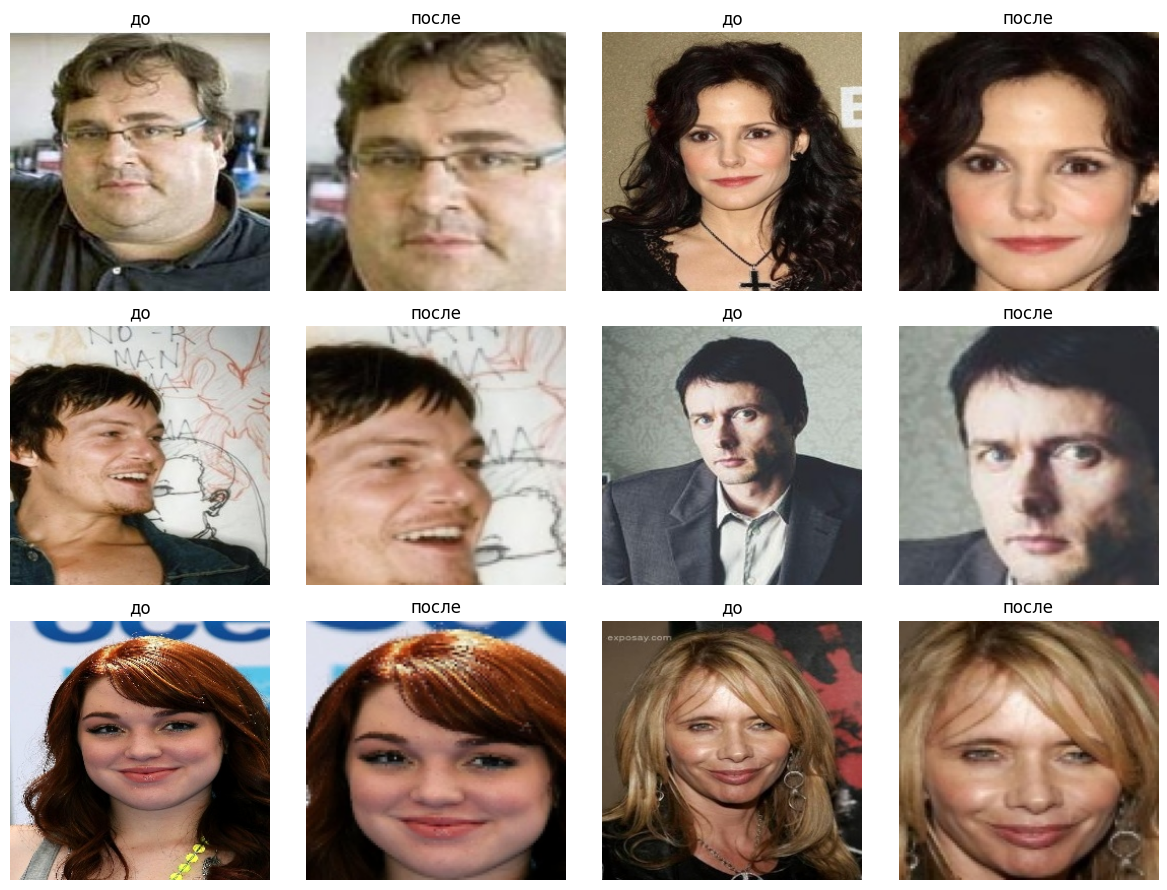

In [42]:
plt.figure(figsize=(12, 9))
for i in range(min(6, len(val_ds))):
    x, _ = val_ds[i]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(DEVICE))[-1][0]
    pts = decode_heatmaps(pred, CFG.input_size, CFG.heatmap_size)
    img = ((x*IMAGENET_STD+IMAGENET_MEAN).permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8).copy()
    aligned, _ = align_face(img, pts, out_size=CFG.aligned_size)
    plt.subplot(3, 4, 2*i+1); plt.imshow(img);     plt.axis("off"); plt.title("до")
    plt.subplot(3, 4, 2*i+2); plt.imshow(aligned); plt.axis("off"); plt.title("после")
plt.tight_layout(); plt.show()

## 8. Датасет выровненных лиц для Задания 2

Прогоняю все отобранные лица через `точки → выравнивание` и раскладываю по папкам:

- `aligned/train/<id>/` и `aligned/val/<id>/` — личности группы train (фото каждого человека делю 85/15);
- `aligned/query/<id>/` и `aligned/distractors/<id>/` — личности, которых сеть не увидит (для ID-Rate).

Разделение делаю прямо по папкам, чтобы точно знать, на чём модель училась, а на чём нет.

In [43]:
from collections import defaultdict
import shutil

aligned_root = os.path.join(CFG.work_dir, "aligned")
if os.path.exists(aligned_root):
    shutil.rmtree(aligned_root)

# для train-личностей заранее выбираем, какие фото уйдут в val (15%)
val_pick = set()
for pid, g in meta[meta.group == "train"].groupby("id"):
    names = g["image_id"].tolist(); random.Random(int(pid)).shuffle(names)
    val_pick.update(names[:max(1, int(0.15 * len(names)))])

def split_dir(row):
    if row["group"] == "train":
        return "val" if row["image_id"] in val_pick else "train"
    return row["group"]

count = defaultdict(int)
for _, r in meta.iterrows():
    img = cv2.imread(os.path.join(crops_dir, r["image_id"]))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        x = ((torch.from_numpy(img).permute(2,0,1).float()/255.0 - IMAGENET_MEAN)/IMAGENET_STD)
        pred = model(x.unsqueeze(0).to(DEVICE))[-1][0]
    pts = decode_heatmaps(pred, CFG.input_size, CFG.heatmap_size)
    aligned, _ = align_face(img, pts, out_size=CFG.aligned_size)

    sub = split_dir(r)
    d = os.path.join(aligned_root, sub, str(r["id"]))
    os.makedirs(d, exist_ok=True)
    cv2.imwrite(os.path.join(d, r["image_id"]), cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR))
    count[sub] += 1

print("Выровнено по папкам:", dict(count))
print("Папка:", aligned_root)

Выровнено по папкам: {'train': 10929, 'distractors': 10154, 'val': 1729, 'query': 1047}
Папка: /content/drive/MyDrive/face_project/aligned


## Итого

Сделал: отобрал и обосновал датасет 10000+ лиц, сохранил `selected_images.csv`; написал Stacked
Hourglass с intermediate supervision и проверил формы; обучил поиск точек; выровнял лица через
similarity-transform (проверка ошибки ≈ 0) и показал «до/после»; собрал датасет выровненных лиц
по папкам.

Файлы на выходе: `hourglass_best.pt`, `selected_images.csv`, папка `aligned/`.

Дальше — Задание 2, обучение распознавателя на CE и ArcFace.